1. Load API keys

In [52]:
import os 
from dotenv import load_dotenv

load_dotenv()

True

2. Import Model

In [53]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "openai/gpt-oss-20b",
    model_provider="openrouter",
    temperature=0
)


3. Create state

In [54]:
from typing import TypedDict

class State(TypedDict):
    question:str
    category:str
    response:str

4. Create classify Node

In [55]:
def classify_question(State):

    prompt = f"""
    You are a question classifier. You will be given a question and you need to classify it into
    Technical, General

    Question: {State['question']}

    Return only the category name
    """
    response = model.invoke(prompt)

    return {
        "category": response.content.strip()
    }

5. Create technical node

In [56]:
def technical(State):

    prompt = f"""
    You are a Technical expert. Based on the question provided, answer in technical words.

    Question: {State['question']}

    """
    result = model.invoke(prompt)

    return {
        "response": result.content
    }

6. Create General node

In [57]:
def general(State):

    prompt = f"""
    You are a General expert. Based on the question provided, answer in simple words.

    Question: {State['question']}

    """
    result = model.invoke(prompt)

    return {
        "response": result.content
    }

7. Create Routing function

In [58]:
def route_question(State):

    if State['category'] == "Technical":
        return "technical"
    else:
        return "general"


8. Create Graph

In [59]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

9. Add nodes

In [60]:
builder.add_node("classify_question", classify_question)
builder.add_node("technical1", technical)
builder.add_node("general2", general)

10. Add edges

In [61]:
builder.add_edge(START, "classify_question")


builder.add_conditional_edges(
    "classify_question", 
    route_question, 
    {
        "technical": "technical1",
        "general": "general2"
    }
)

builder.add_edge("technical1", END)

builder.add_edge("general2", END)

11. Compile

In [62]:
graph = builder.compile()

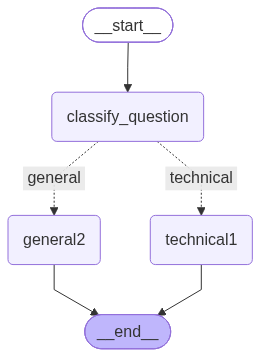

In [63]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

12. Invoke

In [64]:
result = graph.invoke({"question": "what is selfish genes and is it a theory or science"})

13. Print

In [65]:
print(result["response"])

**Selfish genes** is a way of looking at evolution that was popularized by the scientist Richard Dawkins in his book *The Selfish Gene* (1976).  
In simple terms it says:

* Genes are the “real” units of evolution.  
* A gene’s main goal is to make copies of itself in the next generation.  
* The way a gene “acts” (for example, making a trait that helps an organism survive or reproduce) is just a strategy to spread more copies of that gene.

So when we see a bird building a nest, a plant growing tall, or a human sharing food, we can think of those behaviors as the gene’s way of ensuring it gets passed on.

---

### Is it a theory or a science?

* **It is a theory** – a scientific explanation that helps us understand how evolution works.  
* It is **not** a separate science; it is part of evolutionary biology, which is a branch of biology that uses the scientific method to study how living things change over time.

In short, the selfish‑gene idea is a useful theory that fits within the 